### What is Transfer Learning
Transfer learning is a machine learning technique where a model trained on one task is reused (partially or fully) for a different but related task. Instead of training a model from scratch, which can be computationally expensive and require large datasets, transfer learning leverages knowledge from a pre-trained model to improve learning efficiency and performance.
How Transfer Learning Works
1. Pretraining on a Large Dataset
A model is first trained on a large dataset (e.g., ImageNet for images, GPT for text).
The model learns general features, such as edges and shapes in images or syntax and semantics in text.
2. Fine-Tuning for a New Task
The pre-trained model is then adapted to a new, often smaller, dataset.
Some layers may be frozen (not updated), while others are fine-tuned for the specific task.

# why do we frreze the initial layers :

## When a model trains on a massive dataset (like millions of images), it acts like an expert who spent years studying detailed patterns. If you then show that expert a very small new dataset (like only 100 images) and force the entire model to update its weights, a major problem occurs called catastrophic forgetting

### The Problem: Over-Correction

### The model overreacts: With a small dataset, the training process forces the model to adjust quickly to fit only those few images.
### Erasing good weights: The math behind training (gradient descent) will change the weights across the entire network to minimize error on your small dataset.
### Losing generic skills: In doing so, it overwrites the highly optimized, clean filters it previously learned for recognizing universal shapes.
### The result: The model effectively "forgets" how to see general objects and becomes hyper-focused only on your tiny dataset, leading to severe overfitting.
## Why Freezing Prevents This
### Think of freezing as putting a read-only lock on the model's brain.
### Safe foundation: By freezing the initial layers, you guarantee that the model's fundamental ability to see edges, textures, and shapes cannot be altered or corrupted by the new data.
### Targeted learning: The small dataset is only allowed to influence the very end of the network, keeping the core vision system perfectly intact.

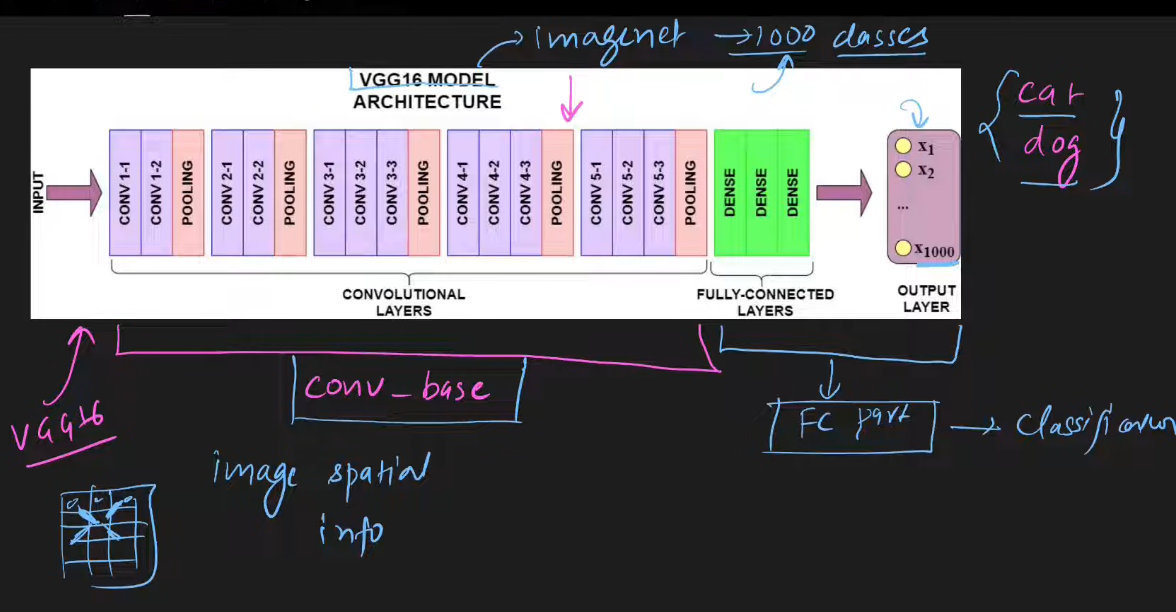

### initial layers captures primitive features like edges and corners and inner layers captures the details so we use initial layers to capture edges and corners and primitive features and as last layers we use to unfreeze them to learn the soecific classes we want to predict and then add our fully connected layers to classify

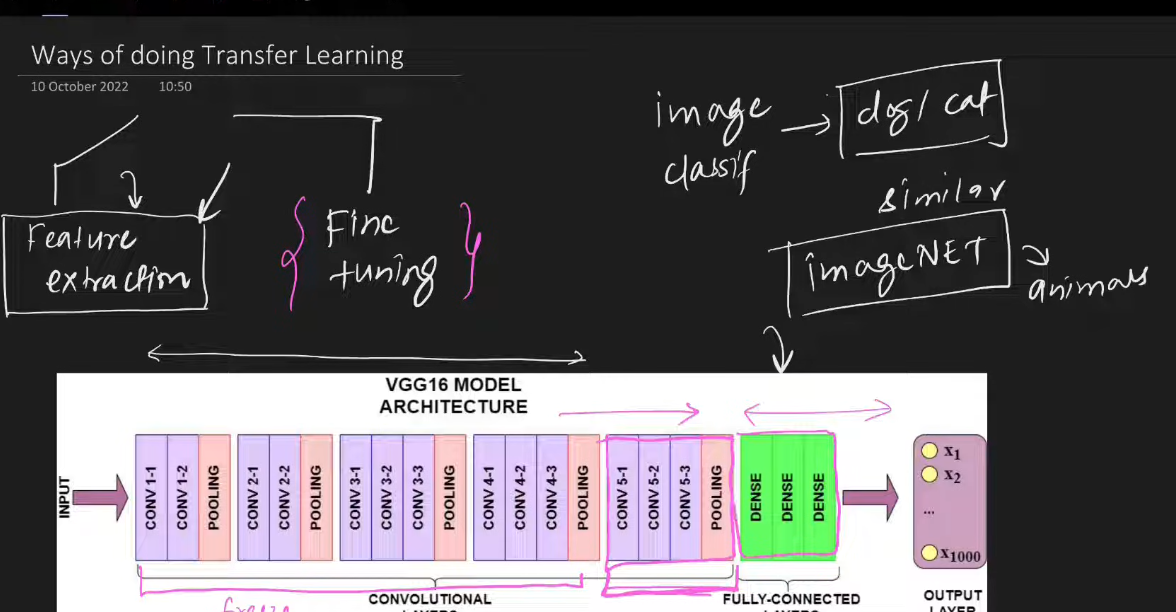

## see in transfer learning there are two approaches
# 1. Feature extraction
# 2. Fine Tuning

## Feature Extraction :Feature ExtractionWhat it is: You freeze all the original convolutional layers of a pre-trained model and only replace or train the final classification head (the dense layers).How it works: The base model acts as a fixed feature extractor, using patterns it already learned from a large dataset like ImageNet to score your new classes
## in feature extration you grab a pre-trained model like suppose an ImageNet Model which has already classes of your desired classification suppose you want to make your model a dog and cat classifier then ImageNet already contains this class means it has already trained on these classes so we will just change our Fully Connected Dense layers nothin else it will work perfectly fine....

## FIne Tuning :What it is: You unfreeze a few of the top (last) convolutional blocks of the base model along with the new dense layers.How it works: You train these un-frozen layers using a very small learning rate so the model can gently adjust the deep visual features to match your new specific images (like phones or tablets
## in fine tuning we train last convolutions by unfreezing them to collect the details as well like see take imageNET which is trained on daily life images and suppose you want to train your model on phone/tablet but the imagenet is not trained on phone/tablet. its missing there so what we will do is unfreeze some convolution layers at the end of the froozen convolution base to train on phone/tablet and then our fully connected dense layer that way we will fine tune our model..

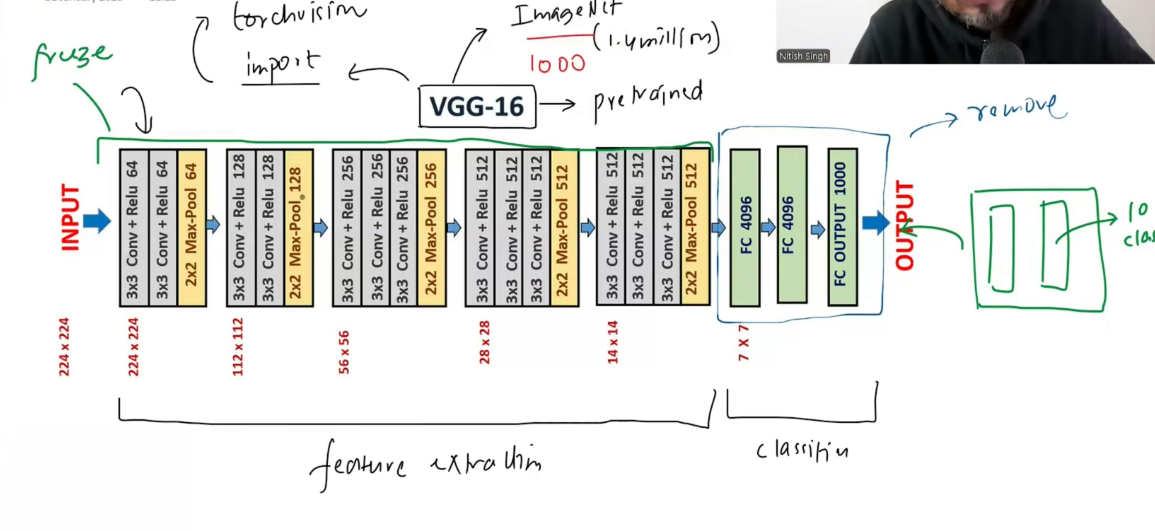

## AS we can see a VGG16 Architecture which is trained on ImageNet which has 1000 classes and we are goiing to learn what actually transfer learning is :
### now see the thing is as you can this is a pre-trained model like it is already been trained on daily images using (ImageNet) dataset which has over 1.4 million images so, then it has been trained using VGG16 architecture now see there at TOP there are 3 Fully coneected dense layers which gives us the Output right and now in transfer learning what we will do is keep the whooole convolution base from the input to the 2*2 Max-Pool 512 layer here in the image you can see and freeze it freezing it means we do not touch this conv base in back propagation like we will not going to change or update the weights of the conv base the weight from previous learning on imageNet dataset will be in use this way and why we do that becasue see guys the conv first layers always captures corners and edges remember the initial layers of conv finds the corners and edges which is universal for all images in a way and this way it could be reusable for us to use for other purposes whatever we want now we will remove the Fully connected layers from the top as you can see 3 fully connected dense layers becasue this layer right now from VGG16 - ImageNet, It has already 1000 classes but we only need some or other classes which not be included in the VGG-16-ImageNet CNN. so we will put our own Fully connected layer there to connect with the Freezed VGG16-ImageNet CNN..

# STEPS

## Import
## Detach Classifier
## Attach Classifier
## Freeze the Conv_Base
## Train

## we have to reshape : reshape (28 * 28) -> 2D matrix -> PIL and PIL
## datatype -> (np.uint8) -> we do this because we will convert 2D matrix into PIL and PIL need uint8 format of matrix in input for it...
## 1D(1,28,28) to 3D(3,28,28) now you have got this tensor
## Tensor to PIL image
## reszie to (3 , 256 , 256)
## centre crop (3, 224, 224)
## tensor scale -> (0, 1)
## normalize => p = (p - mean) / sigma(std_dev) the p is every pixel in a single channel say red channel, means and std_dev will be calc from all pixels in a single channel say for red channel mean and std_dev will come from all pixels in red channel calc mean and std_dev and (every_pixel - mean) /  std_dev


In [ ]:
import torch
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
device

device(type='cuda')

In [ ]:
df = pd.read_csv("/content/fashion_mnist_train.csv")

In [ ]:
df.head(5)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
X = df.iloc[:, 1 :]
y = df.iloc[:, 0]

In [ ]:
X_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
X_train = X_train/255.0
x_test = x_test/255.0

### when performing transfer learning with a pre-trained model (like VGG trained on ImageNet), you must use the ImageNet mean and standard deviation instead of your own. Here is why:

## 1. The Pre-trained Weights Expect "ImageNet-style" DataWhen VGG was trained on millions of ImageNet pictures, it learned to detect edges, textures, and shapes based on a very specific distribution of numbers. The weights (filters) inside the model's first convolutional layers are permanently tuned to look for features shifted by exactly 0.485 and scaled by 0.222.If you normalize Fashion-MNIST using its own mean and standard deviation, you shift the numbers into a completely different distribution. To the pre-trained VGG model, the data will look like gibberish or a heavily distorted image, making its pre-trained feature extractors useless.

## 2. The Golden Rule of Pre-trained ModelsAlways preprocess your new data the exact same way the original model's data was preprocessed.Think of it like buying a machine that is strictly calibrated to process fuel with a specific chemical offset. Even if your fuel is different, you have to add the specific additive the machine expects to prevent it from malfunctioning.

In [ ]:
# Transformations

from torchvision.transforms import transforms

custom_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456, 0.406], std=[0.229, 0.224, 0.225]) # why we use mean and std of VGG explain above
])


In [ ]:
from PIL import Image

class Dataset_loading(Dataset):
  def __init__(self, feature, labels, transform):
    super().__init__()

    self.feature =  feature # torch.tensor(N_feature, dtype=torch.float32).reshape(-1, 1, 28, 28)
    self.labels = labels # torch.tensor(n_labels, dtype=torch.long)
    self.transform = transform

  def __len__(self):
    return len(self.N_features)

  def __getitem__(self, index):
    # return self.N_feature[index], self.n_labels[index]

    # resize to (28 , 28)
    image = self.feature[index].reshape(28,28) # take first row and make it 28 * 28 image

    # convert datatype to uint8
    image = image.astype(np.uint8)

    # black and white (make the 1 channel) into 3 channel
    image = np.stack([image]*3, axis=-1)

    # convert array to PIL
    image = Image.fromarray(image) # to transform we have to convert image into PIL so we did this

    # apply transforms
    image = self.transform(image)

    # returns

    return image , torch.tensor(self.labels[index], dtype=torch.long)

In [ ]:
train_dataset = Dataset_loading(X_train , y_train, transform=custom_transform)

In [ ]:
test_dataset = Dataset_loading(x_test, y_test, transform=custom_transform)

In [ ]:
train_data_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [ ]:
test_data_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# fetch the pretrained model

import torchvision.models as models

vgg16 = models.vgg16(pretrained=True) # pretrained=true i want the weights from VGG16 when it was trained

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 72.4MB/s]


In [ ]:
vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
for params in vgg16.features.parameters():
  params.requires_grad=False

### and we will replace the VGG16's Classifier(Fully connected dense layer) with our own classlifier

In [ ]:
vgg16.classifier = nn.Sequential(
    nn.Linear(25088, 1024),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(512, 10)

)

In [ ]:
vgg16.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=1024, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=1024, out_features=512, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=512, out_features=10, bias=True)
)

In [ ]:
vgg16 = vgg16.to(device)

In [ ]:
learning_rate = 0.001
epoches = 10

In [ ]:
loss = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg16.classifier.parameters(), lr=learning_rate) # initially optim.adam(model.parameters()) this gives the optimizer the NN's learnable params to update using Adam here

In [ ]:
for epoch in range(epoches):

  total_epoch_loss = 0

  for batch_features , batch_labels in train_data_loader:

    batch_features , batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = vgg16(batch_features)


    lossed = loss(outputs , batch_labels)


    optim.zero_grad()


    loss.backward()


    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss/len(train_data_loader)
  print(f"epoch : {epoch} and Loss : {avg_loss}")




In [ ]:
# model.eval()

In [ ]:
loss = 0
correct = 0
total = 0

with torch.no_grad():

  for batch_feature , batch_label in test_data_loader:

    batch_features , batch_labels = batch_features.to(device), batch_labels.to(device)


    output = vgg16(batch_features)


    _, predicted = torch.max(output, 1)

    total = total + batch_labels.shape[0]


    correct = correct + (predicted == batch_labels).sum().item()


print(correct)



In [ ]:

correct = 0
total = 0

with torch.no_grad():

  for batch_feature , batch_label in train_data_loader:

    batch_features , batch_labels = batch_features.to(device), batch_labels.to(device)


    output = vgg16(batch_features)


    _, predicted = torch.max(output, 1)

    total = total + batch_labels.shape[0]


    correct = correct + (predicted == batch_labels).sum().item()


print(correct)